In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


import time
import math
import random
import re
import os
import sys


from utils.util import find_files_with_extension , filter_strings_by_substrings, get_scenario_dict
from utils.util import  get_dataframe_from_filepath
from utils.util import create_directory_if_not_exists
from utils.udp_util import extract_udp_prague_to_dataframe
from utils.plotter import  plot_siftr_graph

In [2]:
# Load data
mainpth="../data/udp_data_2025-04-11"
mainpth="../data/udp_data_2025-04-27"
mainpth="../data/tcp_data_2025-04-28"


graph_directory = os.path.join(mainpth, "Graphs")
create_directory_if_not_exists(graph_directory)

stats_directory = os.path.join(mainpth, "Stats")
create_directory_if_not_exists(stats_directory)


folderpaths = [mainpth+'/server_data', mainpth+'/client1_data', mainpth+'/client2_data']
filenames, filepaths, filedict = find_files_with_extension(folderpaths, '')


scenario_dict = get_scenario_dict(folderpaths)



Directory already exists: ../data/tcp_data_2025-04-28\Graphs
Directory already exists: ../data/tcp_data_2025-04-28\Stats
Unique Mbps and ms Combinations:
8 Mbps, 10 ms
Found 8Mbps_10ms in 1_dualpi2_8Mbps_10ms_ecn_tcp_dsthost.em1.pcap
Found 8Mbps_10ms in 1_dualpi2_8Mbps_10ms_ecn_tcp_dsthost.siftr.log
Found 8Mbps_10ms in 2_dualpi2_8Mbps_10ms_ecn_tcp_dsthost.em1.pcap
Found 8Mbps_10ms in 2_dualpi2_8Mbps_10ms_ecn_tcp_dsthost.siftr.log
Found 8Mbps_10ms in 3_dualpi2_8Mbps_10ms_ecn_tcp_dsthost.em1.pcap
Found 8Mbps_10ms in 3_dualpi2_8Mbps_10ms_ecn_tcp_dsthost.siftr.log
Found 8Mbps_10ms in 1_dualpi2_8Mbps_10ms_ecn_tcp_cubic_src1.em1.pcap
Found 8Mbps_10ms in 1_dualpi2_8Mbps_10ms_ecn_tcp_cubic_src1.siftr.log
Found 8Mbps_10ms in 2_dualpi2_8Mbps_10ms_ecn_tcp_cubic_src1.em1.pcap
Found 8Mbps_10ms in 2_dualpi2_8Mbps_10ms_ecn_tcp_cubic_src1.siftr.log
Found 8Mbps_10ms in 3_dualpi2_8Mbps_10ms_ecn_tcp_cubic_src1.em1.pcap
Found 8Mbps_10ms in 3_dualpi2_8Mbps_10ms_ecn_tcp_cubic_src1.siftr.log
Found 8Mbps_10ms

In [3]:
for scenario in scenario_dict.keys():
    index = "1_dualpi2"

    search_list = ["1_dualpi2", "log", "txt"]
    print()
    print("Start New Scenario")
    print("Scenario", scenario)    

    my_list = scenario_dict[scenario]

    for i, item in enumerate(my_list, start=0):
        print(f"{i}. {item}")




Start New Scenario
Scenario 8Mbps_10ms
0. ../data/tcp_data_2025-04-28/server_data\1_dualpi2_8Mbps_10ms_ecn_tcp_dsthost.em1.pcap
1. ../data/tcp_data_2025-04-28/server_data\1_dualpi2_8Mbps_10ms_ecn_tcp_dsthost.siftr.log
2. ../data/tcp_data_2025-04-28/server_data\2_dualpi2_8Mbps_10ms_ecn_tcp_dsthost.em1.pcap
3. ../data/tcp_data_2025-04-28/server_data\2_dualpi2_8Mbps_10ms_ecn_tcp_dsthost.siftr.log
4. ../data/tcp_data_2025-04-28/server_data\3_dualpi2_8Mbps_10ms_ecn_tcp_dsthost.em1.pcap
5. ../data/tcp_data_2025-04-28/server_data\3_dualpi2_8Mbps_10ms_ecn_tcp_dsthost.siftr.log
6. ../data/tcp_data_2025-04-28/client1_data\1_dualpi2_8Mbps_10ms_ecn_tcp_cubic_src1.em1.pcap
7. ../data/tcp_data_2025-04-28/client1_data\1_dualpi2_8Mbps_10ms_ecn_tcp_cubic_src1.siftr.log
8. ../data/tcp_data_2025-04-28/client1_data\2_dualpi2_8Mbps_10ms_ecn_tcp_cubic_src1.em1.pcap
9. ../data/tcp_data_2025-04-28/client1_data\2_dualpi2_8Mbps_10ms_ecn_tcp_cubic_src1.siftr.log
10. ../data/tcp_data_2025-04-28/client1_data\3_du


Start New Scenario
Scenario 8Mbps_10ms
['../data/tcp_data_2025-04-28/client1_data\\1_dualpi2_8Mbps_10ms_ecn_tcp_cubic_src1.siftr.log', '../data/tcp_data_2025-04-28/client2_data\\1_dualpi2_8Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log']
[]
../data/tcp_data_2025-04-28/client1_data\1_dualpi2_8Mbps_10ms_ecn_tcp_cubic_src1.siftr.log
../data/tcp_data_2025-04-28/client2_data\1_dualpi2_8Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log
Cubic_DCTCP


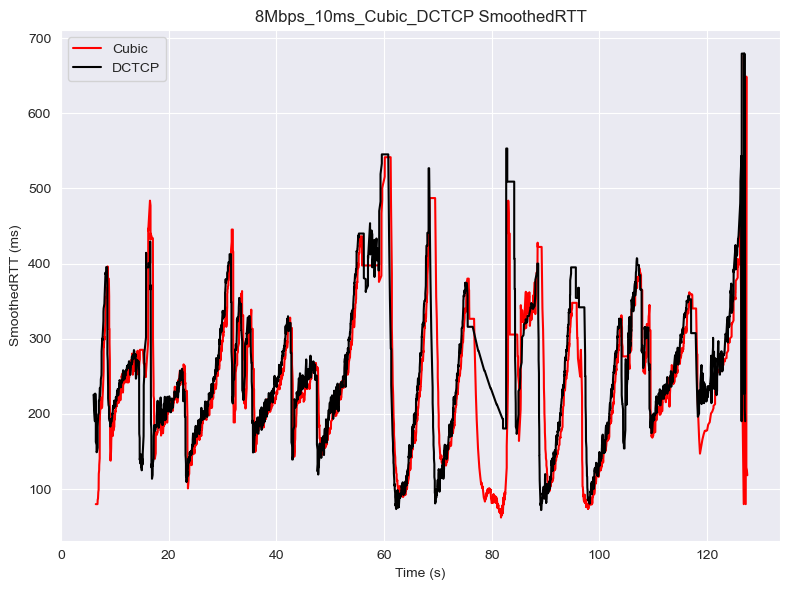

In [4]:
for scenario in scenario_dict.keys():
    index = "1_dualpi2"

    search_list_tcp = [index, "log", "src"]
    filtered_tcp = filter_strings_by_substrings(scenario_dict[scenario], search_list_tcp)

    search_list_udp = [index, "udp_prague_receiver"]
    filtered_udp = filter_strings_by_substrings(scenario_dict[scenario], search_list_udp)

    print()
    print("Start New Scenario")
    print("Scenario", scenario)
    print(filtered_tcp)
    print(filtered_udp)


    ttf1 = get_dataframe_from_filepath(filtered_tcp[0])
    ttf1 = ttf1[ttf1['ForeignPort'] == "5102"]
    ttf2 = get_dataframe_from_filepath(filtered_tcp[1])
    ttf2 = ttf2[ttf2['ForeignPort'] == "5103"]




        # Define paths
    paths = {
        "Cubic": ttf1,
        "DCTCP": ttf2,
    }

    keys_string = "_".join(paths.keys())
    print(keys_string)

    scenario += str("_"+keys_string)

    plot_siftr_graph(paths=paths,
                    ycolumn="SmoothedRTT",
                    title=f"{scenario} SmoothedRTT",
                    xlabel="Time (s)",
                    ylabel="SmoothedRTT (ms)",
                    filename=f'{scenario}_SmoothedRTT',
                    graph_directory=graph_directory,
    )


In [5]:
os.path.getsize(filtered_tcp[0])


4153008

In [6]:
os.path.getsize(filtered_tcp[1])

5172866